# BERT XAI

This notebook reproduces the experiments using the refactored package modules instead of inline code.

In [1]:
import pathlib
import sys

ROOT = pathlib.Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", ROOT)
print("Using src path:", SRC)

Project root: /users/eleves-a/2022/vincent.zhou/Documents/XAI/XAI
Using src path: /users/eleves-a/2022/vincent.zhou/Documents/XAI/XAI/src


In [2]:
from xai_bert import (
    BertHiddenStateRunner,
    anisotropy_all_layers_before_after,
    compare_outlier_stats_before_after_clipping,
    compute_mean_vectors_over_corpus,
    compute_outlier_dimension_stats_over_corpus,
    flatten_valid_tokens,
    load_sst2_text_splits,
    context_words_for_text,
    plot_anisotropy_before_after,
    plot_mean_vectors,
    print_anisotropy_results,
    print_before_after_comparison,
    print_outlier_stats,
    run_probe_for_selected_layers_with_splits,
    select_primary_outlier_dims,
    top_k_dims,
    compute_word_self_similarity_selected_layers
)

In [3]:
runner = BertHiddenStateRunner(model_name="bert-base-uncased", max_length=64)

texts = [
    "The cat is sleeping on the sofa.",
    "A transformer model produces contextualized embeddings.",
    "This paper studies positional artifacts in BERT.",
    "Layer normalization can amplify certain dimensions.",
    "The quick brown fox jumps over the lazy dog.",
] * 200

print("num texts:", len(texts))
print("num unique texts:", len(set(texts)))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


num texts: 1000
num unique texts: 5


In [4]:
train_texts, val_texts, test_texts = load_sst2_text_splits(
    max_train=5000,
    seed=42,
)

print("SST-2 split sizes:")
print("  train:", len(train_texts))
print("  val  :", len(val_texts))
print("  test :", len(test_texts))

SST-2 split sizes:
  train: 5000
  val  : 872
  test : 872


## Experiment 1: Mean Vectors Per Layer

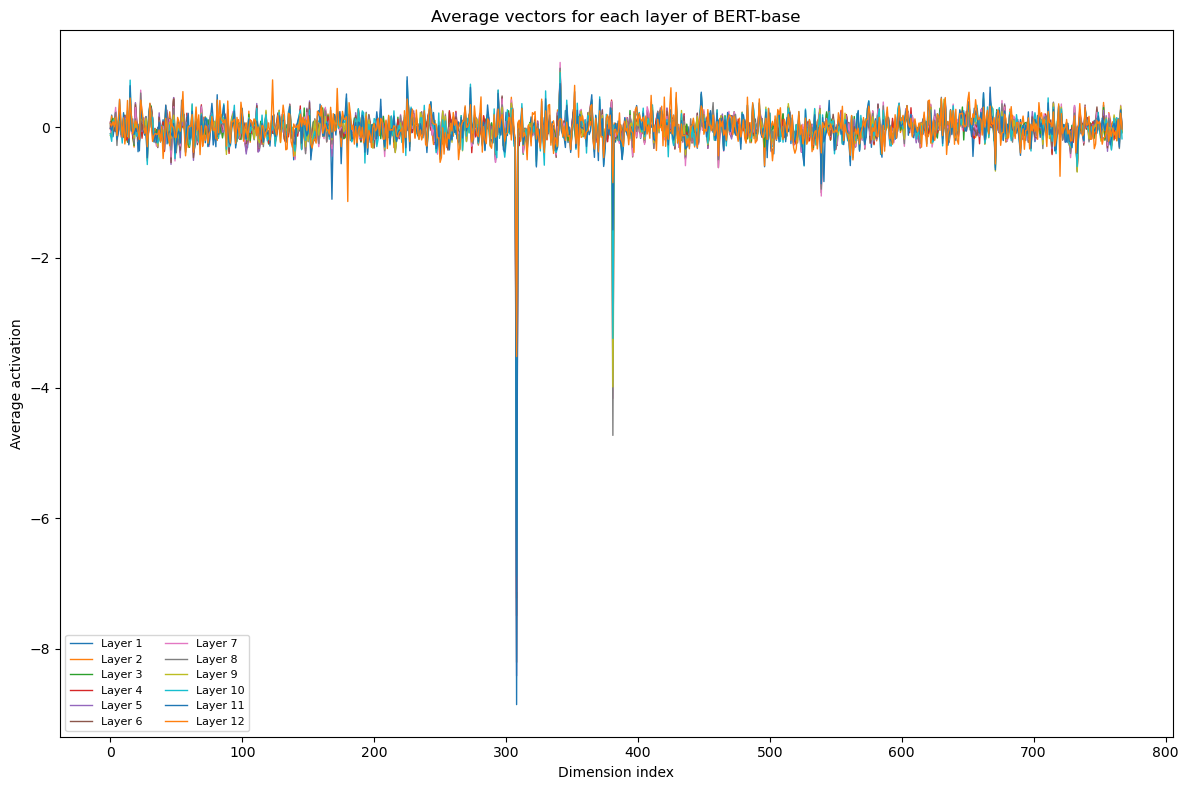

In [5]:
mean_vectors = compute_mean_vectors_over_corpus(
    runner=runner,
    texts=train_texts,
    batch_size=16,
    exclude_embedding_layer=True,
    remove_special_tokens=False,
)

plot_mean_vectors(mean_vectors)

## Experiment 2: Outlier Dimensions

In [6]:
outlier_stats = compute_outlier_dimension_stats_over_corpus(
    runner=runner,
    texts=train_texts,
    batch_size=16,
    exclude_embedding_layer=True,
    remove_special_tokens=False,
)

print_outlier_stats(outlier_stats)

layer_3_min_top10 = top_k_dims(outlier_stats[3]["min_counter"], k=10)
print("Top-10 min dims for layer 3:", layer_3_min_top10)

Layer 1
  n_tokens      : 66303
  top min dim   : 308 (82.75%)
  top max dim   : 139 (7.54%)

Layer 2
  n_tokens      : 66303
  top min dim   : 308 (97.64%)
  top max dim   : 341 (6.16%)

Layer 3
  n_tokens      : 66303
  top min dim   : 308 (89.51%)
  top max dim   : 545 (6.97%)

Layer 4
  n_tokens      : 66303
  top min dim   : 308 (90.38%)
  top max dim   : 514 (6.87%)

Layer 5
  n_tokens      : 66303
  top min dim   : 308 (91.19%)
  top max dim   : 341 (7.35%)

Layer 6
  n_tokens      : 66303
  top min dim   : 308 (90.60%)
  top max dim   : 308 (7.54%)

Layer 7
  n_tokens      : 66303
  top min dim   : 308 (89.00%)
  top max dim   : 341 (8.06%)

Layer 8
  n_tokens      : 66303
  top min dim   : 308 (83.89%)
  top max dim   : 308 (7.62%)

Layer 9
  n_tokens      : 66303
  top min dim   : 308 (80.85%)
  top max dim   : 308 (7.79%)

Layer 10
  n_tokens      : 66303
  top min dim   : 308 (85.27%)
  top max dim   : 123 (6.47%)

Layer 11
  n_tokens      : 66303
  top min dim   : 308 (88.

## Experiment 3: Single-Layer Clipping Check

In [7]:
batch_out = runner.run_batch(texts[:16])

flat_l1 = flatten_valid_tokens(
    batch_output=batch_out,
    layer_idx=1,
    remove_special_tokens=False,
)

dims_to_clip = select_primary_outlier_dims(outlier_stats[1], mode="min")
comparison = compare_outlier_stats_before_after_clipping(
    flat_layer=flat_l1,
    dims_to_clip=dims_to_clip,
)

print_before_after_comparison(comparison)

Clipped dims: [308]
Before clipping:
  top min dim: 308 (78.95%), top max dim: 139 (8.42%)
After clipping:
  top min dim: 168 (23.68%), top max dim: 139 (8.42%)


## Experiment 4: Anisotropy Before/After Clipping

Layer 1
  clipped dims : [308]
  before       : 0.187561
  after        : 0.096944
  delta        : -0.090617

Layer 2
  clipped dims : [308]
  before       : 0.245137
  after        : 0.099419
  delta        : -0.145718

Layer 3
  clipped dims : [308]
  before       : 0.223144
  after        : 0.112804
  delta        : -0.110341

Layer 4
  clipped dims : [308]
  before       : 0.247070
  after        : 0.123073
  delta        : -0.123997

Layer 5
  clipped dims : [308]
  before       : 0.284131
  after        : 0.137463
  delta        : -0.146668

Layer 6
  clipped dims : [308]
  before       : 0.290147
  after        : 0.157097
  delta        : -0.133050

Layer 7
  clipped dims : [308]
  before       : 0.303140
  after        : 0.211068
  delta        : -0.092073

Layer 8
  clipped dims : [308]
  before       : 0.316634
  after        : 0.254349
  delta        : -0.062285

Layer 9
  clipped dims : [308]
  before       : 0.296040
  after        : 0.253695
  delta        : -0.042345

L

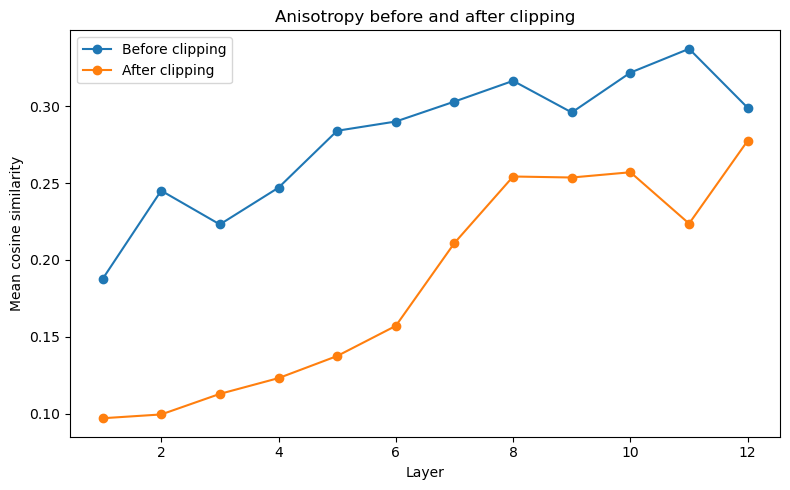

In [8]:
anisotropy_results = anisotropy_all_layers_before_after(
    runner=runner,
    texts=texts,
    outlier_stats=outlier_stats,
    batch_size=16,
    remove_special_tokens=False,
    exclude_embedding_layer=True,
    clip_mode="min",
    n_pairs=1000,
    seed=42,
)

print_anisotropy_results(anisotropy_results)
plot_anisotropy_before_after(anisotropy_results)

## Experiment 5: Position Probe on SST-2 (GLUE)

In [9]:
layer_probe_results = run_probe_for_selected_layers_with_splits(
    runner=runner,
    train_texts=train_texts,
    val_texts=val_texts,
    test_texts=test_texts,
    layers=(1, 3, 6, 9, 12),
    max_position=300,
    build_batch_size=16,
    probe_batch_size=128,
    num_epochs=5,
    lr=1e-3,
    remove_special_tokens=True,
)

Layer 1: {'loss': 0.01393888912555967, 'acc': 0.9988305337018925}
Layer 3: {'loss': 0.06061223738351744, 'acc': 0.9948968743355305}
Layer 6: {'loss': 0.6742295553246737, 'acc': 0.7729109079311078}
Layer 9: {'loss': 1.315554145141381, 'acc': 0.5169041037635552}
Layer 12: {'loss': 1.920791322060045, 'acc': 0.3639166489474803}


## Experiment 6: Self similarity

Given a word $w$ and $n$ different sentences $s_1, s_2, \dots, s_n$ which contain such word, $f_l^i(w)$ is the internal representation of $w$ in sentence $s_i$ in the $l^{th}$ layer. The average self-similarity of $w$ in the $l^{th}$ layer is then defined as:

\begin{equation}
\text{SelfSim}_l(w) = \frac{\sum_{i=1}^n \sum_{j=i+1}^n \cos\left(f_l^i(w), f_l^j(w)\right)}{n(n - 1)}
\end{equation}

In [10]:
train_texts_total, _, _ = load_sst2_text_splits(max_train=None, max_val=0, max_test=0, seed=42)
selfsim_target_words = context_words_for_text(train_texts_total, n_word=10, n_sentence_min=10, random_select=True)

In [11]:
print("Selected target words for self-similarity analysis:", selfsim_target_words)

Selected target words for self-similarity analysis: ['buffs', 'apart', 'screen', 'wanders', 'york', 'fat', 'opening', 'speedy', 'latin', 'ring']


In [18]:
layers = (1, 3, 6, 9, 12)

In [19]:
dims_to_clip_by_layer = {
    layer_idx: stats["top_min_dim"]
    for layer_idx, stats in outlier_stats.items()
}
self_similarity_results = []
for word in selfsim_target_words:
	sentences_with_word = [
		text for text in train_texts_total
		if word in text.split()
	]

	self_similarity_results.append(
		compute_word_self_similarity_selected_layers(
			runner=runner,
			texts=sentences_with_word,
			dims_to_clip=dims_to_clip_by_layer,
		layer_indices=layers,
		anisotropy=anisotropy_results,
		)
	)

In [34]:
self_similarity_results_abs = []
for i in range(len(self_similarity_results)):
    tmp = {}
    for layer in layers:
        tmp[layer] = {
			"before": abs(self_similarity_results[i][layer]["before"]),
			"after": abs(self_similarity_results[i][layer]["after"]),
		}
    self_similarity_results_abs.append(tmp)

In [35]:
results = {"before": {layer:0 for layer in layers}, "after": {layer:0 for layer in layers}}
for i in range(len(self_similarity_results)):
    for layer in layers:
        results["before"][layer] += self_similarity_results_abs[i][layer]["before"]
        results["after"][layer] += self_similarity_results_abs[i][layer]["after"]

In [36]:
import matplotlib.pyplot as plt

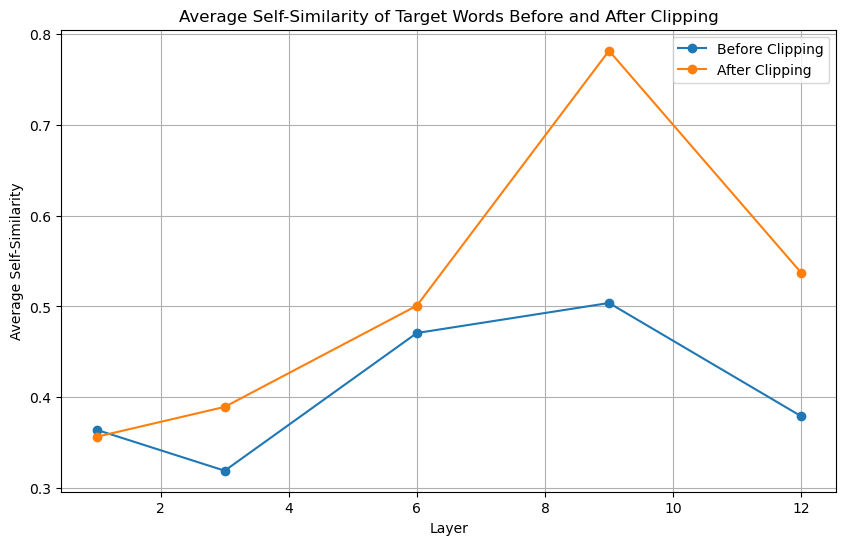

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(layers, [results["before"][layer] for layer in layers], marker="o", label="Before Clipping")
plt.plot(layers, [results["after"][layer] for layer in layers], marker="o", label="After Clipping")
plt.xlabel("Layer")
plt.ylabel("Average Self-Similarity")
plt.title("Average Self-Similarity of Target Words Before and After Clipping")
plt.legend()
plt.grid()
plt.show()

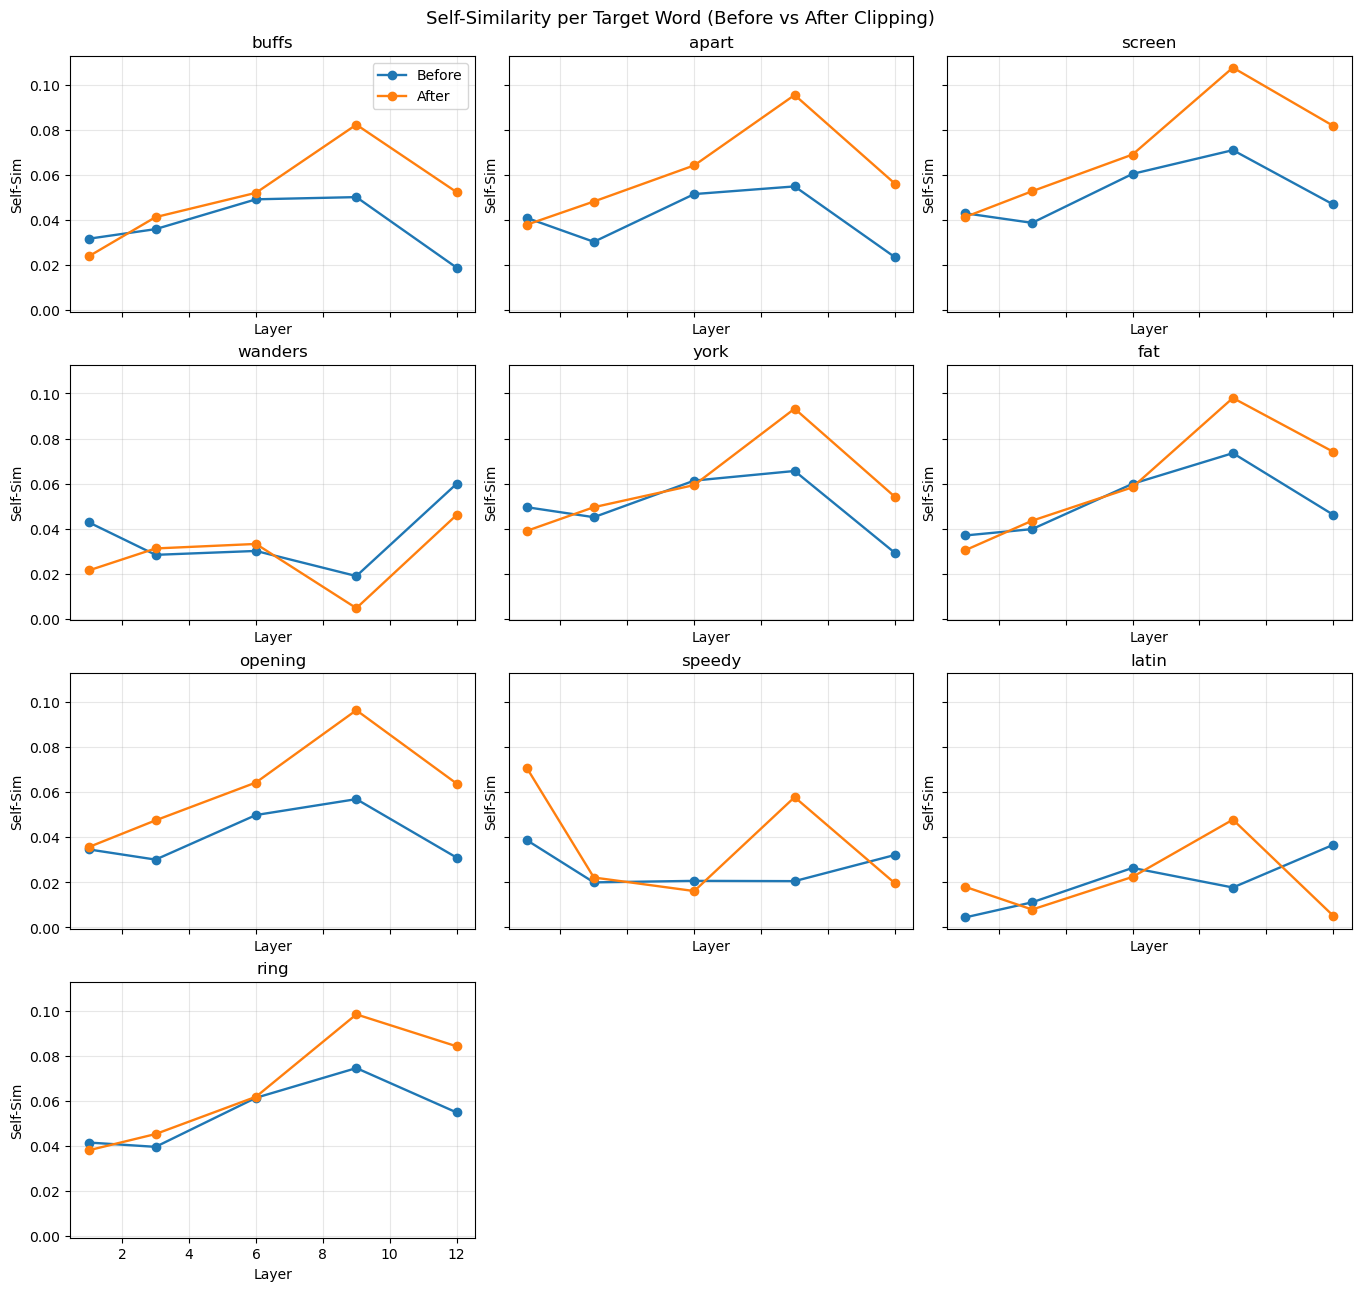

In [39]:
import math

n_words = len(selfsim_target_words)
n_cols = 3
n_rows = max(1, math.ceil(n_words / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 3.2 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
 )

# Normalize axes into a flat list for consistent indexing
if n_rows == 1 and n_cols == 1:
    axes = [axes]
elif n_rows == 1 or n_cols == 1:
    axes = list(axes)
else:
    axes = axes.flatten()

for idx, word in enumerate(selfsim_target_words):
    ax = axes[idx]
    per_word = self_similarity_results_abs[idx]
    before_vals = [per_word[layer]["before"] for layer in layers]
    after_vals = [per_word[layer]["after"] for layer in layers]

    ax.plot(layers, before_vals, marker="o", linewidth=1.7, label="Before")
    ax.plot(layers, after_vals, marker="o", linewidth=1.7, label="After")
    ax.set_title(word)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Self-Sim")
    ax.grid(alpha=0.3)

# Hide any unused subplot slots
for idx in range(n_words, len(axes)):
    axes[idx].axis("off")

# Show one legend only to keep panels clean
if n_words > 0:
    axes[0].legend(loc="best")

fig.suptitle("Self-Similarity per Target Word (Before vs After Clipping)", fontsize=13)
plt.show()